In [1]:
using Combinatorics, ITensors, JLD2, ITensorMPS, PyPlot, NPZ, JSON
using NLopt
using Zygote 
using LinearAlgebra
include("../../src/apply_gate_as_mpo.jl");
include("../../src/gates_utils.jl");
#Script with operations w/ majoranas
include("../../src/majo_machinery.jl");
#Script with possible initial configurations
include("../../src/initial_circuits.jl");
#Script with potential quantum gates
include("../../src/gates_circuit.jl");

In [2]:
@show Threads.nthreads()

Threads.nthreads() = 4


4

In [3]:
if isdefined(Main, :Plots)
    @warn "Plots.jl is currently loaded in this session!"
end

PyPlot.matplotlib.style.use("default")
PyPlot.matplotlib.style.use("../../config/unified_plots.mplstyle")
plot_args = JSON.parsefile("../../config/unified_plots.json")

make_kwargs(dict) = Dict(Symbol(k) => v for (k, v) in dict)

make_kwargs (generic function with 1 method)

In [4]:
#number qubits 
nq = 50
# Number of points to sample
num_points = 1000
single_qubit_index = nq ÷ 2  # Index of the single qubit to measure
# terms involved in the observable
ops_list = [(single_qubit_index, :z)]  #list of tuples (qubit_index, pauli_operator)
coeffs_list = [1.0]  #list of coefficients for each term in ops_list
num_terms = length(ops_list);

In [5]:
# dataset name
dataset_name = "Local_U_$(nq)q_$(num_terms)_obs_terms_$(num_points)N"

"Local_U_50q_1_obs_terms_1000N"

In [7]:
# Load the dataset from npy files

random_coeffs = npzread("../data/$(dataset_name)/coeffs_$(nq)q.npy")
println("random_coeffs loaded")

t_list = npzread("../data/$(dataset_name)/t_list_$(nq)q.npy")
println("t_list loaded")

outputs = npzread("../data/$(dataset_name)/outputs_$(nq)q.npy")
println("outputs loaded")

kernels = stack([npzread("../data/$(dataset_name)/kernels_exact_$(nq)q/k_qubit_$(qubit).npy") for qubit in 1:nq])

obs_norm = coeffs_list' * coeffs_list  # note that these coefficients are with respect to the unnormalized majorana products, but so are the feature vectors, so this is consistent and cancels out
kernel_factor = 1/2 * obs_norm 
kernels = [kernels[:, :, i] for i in 1:size(kernels, 3)]
println("K loaded $(length(kernels))")


println("kernel_factor: ", kernel_factor)


random_coeffs loaded
t_list loaded
outputs loaded
K loaded 50
kernel_factor: 0.5


In [8]:
using AbstractGPs, KernelFunctions

struct PrecomputedIndexKernel{T<:AbstractMatrix} <: KernelFunctions.Kernel
    K::T
end

# Fast path: build the whole kernel matrix for integer index inputs
KernelFunctions.kernelmatrix(k::PrecomputedIndexKernel,
                             x::AbstractVector{<:Integer},
                             y::AbstractVector{<:Integer}; obsdim=1) = k.K[x, y]

# (Optional) scalar fallback:
(k::PrecomputedIndexKernel)(i::Integer, j::Integer) = k.K[i, j]

In [9]:
function plot_qgp!(ax, yobs, train_idxs, μ, σ; panel_title="", plot_args=plot_args)
    """
    Plots a generic QGP prediction.
    Assumes `t_list`, `outputs`, and `plot_args` exist in the global scope.
    """
    # 1. True dynamics
    true_line = ax.plot(t_list, outputs; make_kwargs(plot_args["true_function"])...)[1]
                    
    # 2. Training Data
    # Extract the kwargs and dynamically override just the label
    obs_kwargs = make_kwargs(plot_args["observations"])
    obs_kwargs[:label] = "$(length(train_idxs)) $(plot_args["observations"]["label"])" 
    obs_pts = ax.plot(t_list[train_idxs], yobs; obs_kwargs...)[1]
               
    # 3. QGP Prediction
    qgp_band = ax.fill_between(t_list, μ .- σ, μ .+ σ; make_kwargs(plot_args["gp_stds"])...)
    qgp_line = ax.plot(t_list, μ; make_kwargs(plot_args["gp_mean"])...)[1]
    
    if !isempty(panel_title)
        ax.set_title(panel_title)
    end

    legend_handles = [true_line, obs_pts, (qgp_line, qgp_band)]
    legend_labels = [true_line.get_label(), obs_pts.get_label(), qgp_line.get_label()]

    ax.set_xlabel(plot_args["regression"]["xlabel"])
    ax.set_ylabel(plot_args["regression"]["ylabel"])
    
    return ax, legend_handles, legend_labels
end

plot_qgp! (generic function with 1 method)

In [10]:
using LinearAlgebra, Statistics, Distributions

function psdify(K::AbstractMatrix; mode::Symbol=:semicircle, eps::Real=1e-5, σ²_kernel_entries=NaN)
    A = (K + K')/2
    F = eigen(A)                        # A = Q * Diagonal(λ) * Q'
    if mode == :shift
        λneg = minimum(F.values) - eps   
        Kpsd = A - diagm(fill(λneg, size(A,1)))
        print("shifted by $λneg to make PSD (Wigner circle $(2*sqrt(size(A,1))*(1/sqrt(nshots_kernel))))\n")
    elseif mode == :trim
        λtrim = max.(F.values, eps)             # clamp
        Kpsd = F.vectors * diagm(λtrim) * F.vectors'
    elseif mode == :semicircle
        λtrim = F.values

        if isnan(σ²_kernel_entries)
            error("σ²_kernel_entries must be provided for semicircle mode")
        end

        λshift = 2*sqrt(size(A,1))*sqrt(σ²_kernel_entries)  # Wigner semi-circle shift

        # check if this guarantees PSD, otherwise shift more:
        λneg = minimum(F.values) 
        if λneg < -λshift
            println("Wigner semicircle shift $λshift insufficient, shift by most negative eigenvalue instead $(-λneg) + eps $(eps)")
            λshift = -λneg + eps
        end
        Kpsd = A + diagm(fill(λshift, size(A,1)))
    else
        error("Not Implemented yet")
    end
    Kpsd
end

function add_noise_2_kernel(K::Matrix, nshots)
    ker = diagm(ones(size(K,1)))
    for i in 1:size(ker, 1)
        for j in i:size(ker, 2)  # also on diagonal here or do we know the exact value?
            _ovp = K[i,j]
            #p = 0.5*(1 + _ovp)
            #d = Normal(p, sqrt(p*(1-p)/nshots))
            d = Normal(_ovp, 1/sqrt(nshots))
            ovp = rand(d)
            #ovp = 2*ovp - 1
            ker[i,j] = ovp
            ker[j,i] = ovp
        end
    end
    ker
end

add_noise_2_kernel (generic function with 1 method)

In [11]:
ntp = 15
t_train_margin = 1.0
nshots_obs = 1000
nshots_kernel = 1000 #* (1000000 ÷ 15985)
σ²_obs = 1/nshots_obs

0.001

In [12]:
# Dataset train - test split:

t_span = maximum(t_list) - minimum(t_list)

spacing = round(Int, num_points * t_train_margin / t_span / ntp)
@assert spacing ≥ 1
train_idxs = collect(0:ntp-1) * spacing .+ 1
test_idxs = setdiff(1:length(outputs), train_idxs);

In [13]:
# Add noise to observations 

# set seed 
Random.seed!(123)
y_obs = outputs[train_idxs] + randn(length(train_idxs)) .* (1/sqrt(nshots_obs));
#ker = add_noise_2_kernel(K, nshots_kernel)


15-element Vector{Float64}:
 -0.7962283744236498
 -0.8544554002678163
 -0.8958238232250938
 -0.8150208308549928
 -0.604761601356814
 -0.4783689928595541
 -0.4134586454578602
 -0.2025235596816278
  0.1042015399764418
  0.25371490586146445
  0.17083369659935188
  0.12088693673352516
  0.059076518906692105
 -0.10085543067862969
 -0.07208641231158008

In [14]:
# test optimal kernel weights
θ = zeros(length(kernels)) / sqrt(length(kernels))  
θ[nq ÷ 2] = 1.0

1.0

In [15]:

ker_exact = sum(θ.^2 .* kernels) # combine kernels linearly
precomp_k_exact = PrecomputedIndexKernel(ker_exact)
f_gp_exact = GP(precomp_k_exact)  # or GP(ConstMean(c), k) if you want a nonzero mean    
fx_exact  = f_gp_exact(train_idxs, 1e-10)        # or f(train_idxs, σ²_vec) for heteroscedastic
post_exact = posterior(fx_exact, outputs[train_idxs])

pred_exact = post_exact(1:length(t_list))              
μ_exact = mean(pred_exact)
σ_exact = sqrt.(abs.(var(pred_exact)))
fig, ax = plt.subplots(figsize=(plot_args["fig_width_inches_half"], 2.5))
ax, handles, labels = plot_qgp!(ax, outputs[train_idxs], train_idxs, μ_exact, σ_exact; 
                                panel_title="Local unitary QGP (exact)")
ax.legend(handles, labels)

isdir("../plots/$(dataset_name)") || mkpath("../plots/$(dataset_name)")
fig.savefig("../plots/$(dataset_name)/qgp_exact_$(ntp)ntp.pdf", bbox_inches="tight")

In [16]:
# Initial kernel weights 

θ = ones(length(kernels)) / length(kernels)

50-element Vector{Float64}:
 0.02
 0.02
 0.02
 0.02
 0.02
 0.02
 0.02
 0.02
 0.02
 0.02
 ⋮
 0.02
 0.02
 0.02
 0.02
 0.02
 0.02
 0.02
 0.02
 0.02

In [17]:

ker_exact = sum(θ .* kernels) # combine kernels linearly
precomp_k_exact = PrecomputedIndexKernel(ker_exact)
f_gp_exact = GP(precomp_k_exact)  # or GP(ConstMean(c), k) if you want a nonzero mean    
fx_exact  = f_gp_exact(train_idxs, 1e-10)        # or f(train_idxs, σ²_vec) for heteroscedastic
post_exact = posterior(fx_exact, outputs[train_idxs])


pred_exact_init = post_exact(1:length(t_list))              
μ_exact_init = mean(pred_exact_init)
σ_exact_init = sqrt.(abs.(var(pred_exact_init)))
fig, ax = plt.subplots(figsize=(plot_args["fig_width_inches_half"], 2.5))
ax, handles, labels = plot_qgp!(ax, outputs[train_idxs], train_idxs, μ_exact_init, σ_exact_init; 
                                panel_title="Init QGP (exact)")
ax.legend(handles, labels)

isdir("../plots/$(dataset_name)") || mkpath("../plots/$(dataset_name)")
fig.savefig("../plots/$(dataset_name)/qgp_exact_$(ntp)ntp.pdf", bbox_inches="tight")

In [18]:
function make_loss_function(x_train, y_train, kernels)
    
    # The pure mathematical function (unchanged)
    function nll(params)
        # Re-construct kernel from weights
        # Note: Ensure this operation is Zygote-compatible (simple sums are fine)
        ker_exact = sum(params .* kernels) 
        
        precomp_k_exact = PrecomputedIndexKernel(ker_exact)
        f_gp_exact = GP(precomp_k_exact)
        
        # Adding small noise for numerical stability
        fx_exact = f_gp_exact(x_train, 1e-6)
        
        return -logpdf(fx_exact, y_train)
    end

    # The NLopt Interface
    function nlopt_objective(params, grad)
        
        # 1. Compute Value AND Gradient in one go (efficient)
        if length(grad) > 0
            # Zygote.withgradient returns (value, (gradient_tuple,))
            val, back = Zygote.pullback(nll, params)
            
            # Run the backprop
            grads = back(1.0)[1] # Get gradient wrt the first argument (params)
            
            # Copy result into NLopt's buffer
            # We handle 'nothing' which Zygote returns for non-differentiable constants
            if grads !== nothing
                grad .= grads
            else
                fill!(grad, 0.0)
            end
            
            return val
        else
            # Only value requested
            return nll(params)
        end
    end

    return nlopt_objective
end

# --- Setup Optimization ---

# 1. Initialize the optimizer (LD_LBFGS = Low-storage BFGS with bounds)
n_params = length(θ)
opt = Opt(:LD_LBFGS, n_params)

# 2. Set the constraints (Unit Hypercube: 0.0 to 1.0)
lower_bounds!(opt, zeros(n_params))
upper_bounds!(opt, ones(n_params))

# 3. Set the objective function
obj_func = make_loss_function(train_idxs, outputs[train_idxs], kernels)
min_objective!(opt, obj_func)

# 4. Set tolerances (optional but recommended)
ftol_rel!(opt, 1e-16)
#xtol_rel!(opt, 1e-10)
maxeval!(opt, 1000) # Limit iterations/evaluations

# 5. Run
# (minf is the minimum loss value, minx is the optimized θ, ret is the status)
(minf, minx, ret) = optimize(opt, θ)

# Update your theta
θ = minx
println("Optimization finished with status: $ret")
println("Min Loss: $minf")

Optimization finished with status: SUCCESS
Min Loss: -61.40342568694693


In [19]:

ker_exact = sum(θ .* kernels) # combine kernels linearly
precomp_k_exact = PrecomputedIndexKernel(ker_exact)
f_gp_exact = GP(precomp_k_exact)  # or GP(ConstMean(c), k) if you want a nonzero mean    
fx_exact  = f_gp_exact(train_idxs, 1e-10)        # or f(train_idxs, σ²_vec) for heteroscedastic
post_exact = posterior(fx_exact, outputs[train_idxs])


pred_exact_optim = post_exact(1:length(t_list))              
μ_exact_optim = mean(pred_exact_optim)
σ_exact_optim = sqrt.(abs.(var(pred_exact_optim)))
fig, ax = plt.subplots(figsize=(plot_args["fig_width_inches_half"], 2.5))
ax, handles, labels = plot_qgp!(ax, outputs[train_idxs], train_idxs, μ_exact_optim, σ_exact_optim; 
                                panel_title="Optimized QGP (exact)")
ax.legend(handles, labels)

isdir("../plots/$(dataset_name)") || mkpath("../plots/$(dataset_name)")
fig.savefig("../plots/$(dataset_name)/qgp_exact_$(ntp)ntp_optim.pdf", bbox_inches="tight")

In [20]:
sort(θ)

50-element Vector{Float64}:
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 ⋮
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.49999845664230075

# Combined plot for paper:

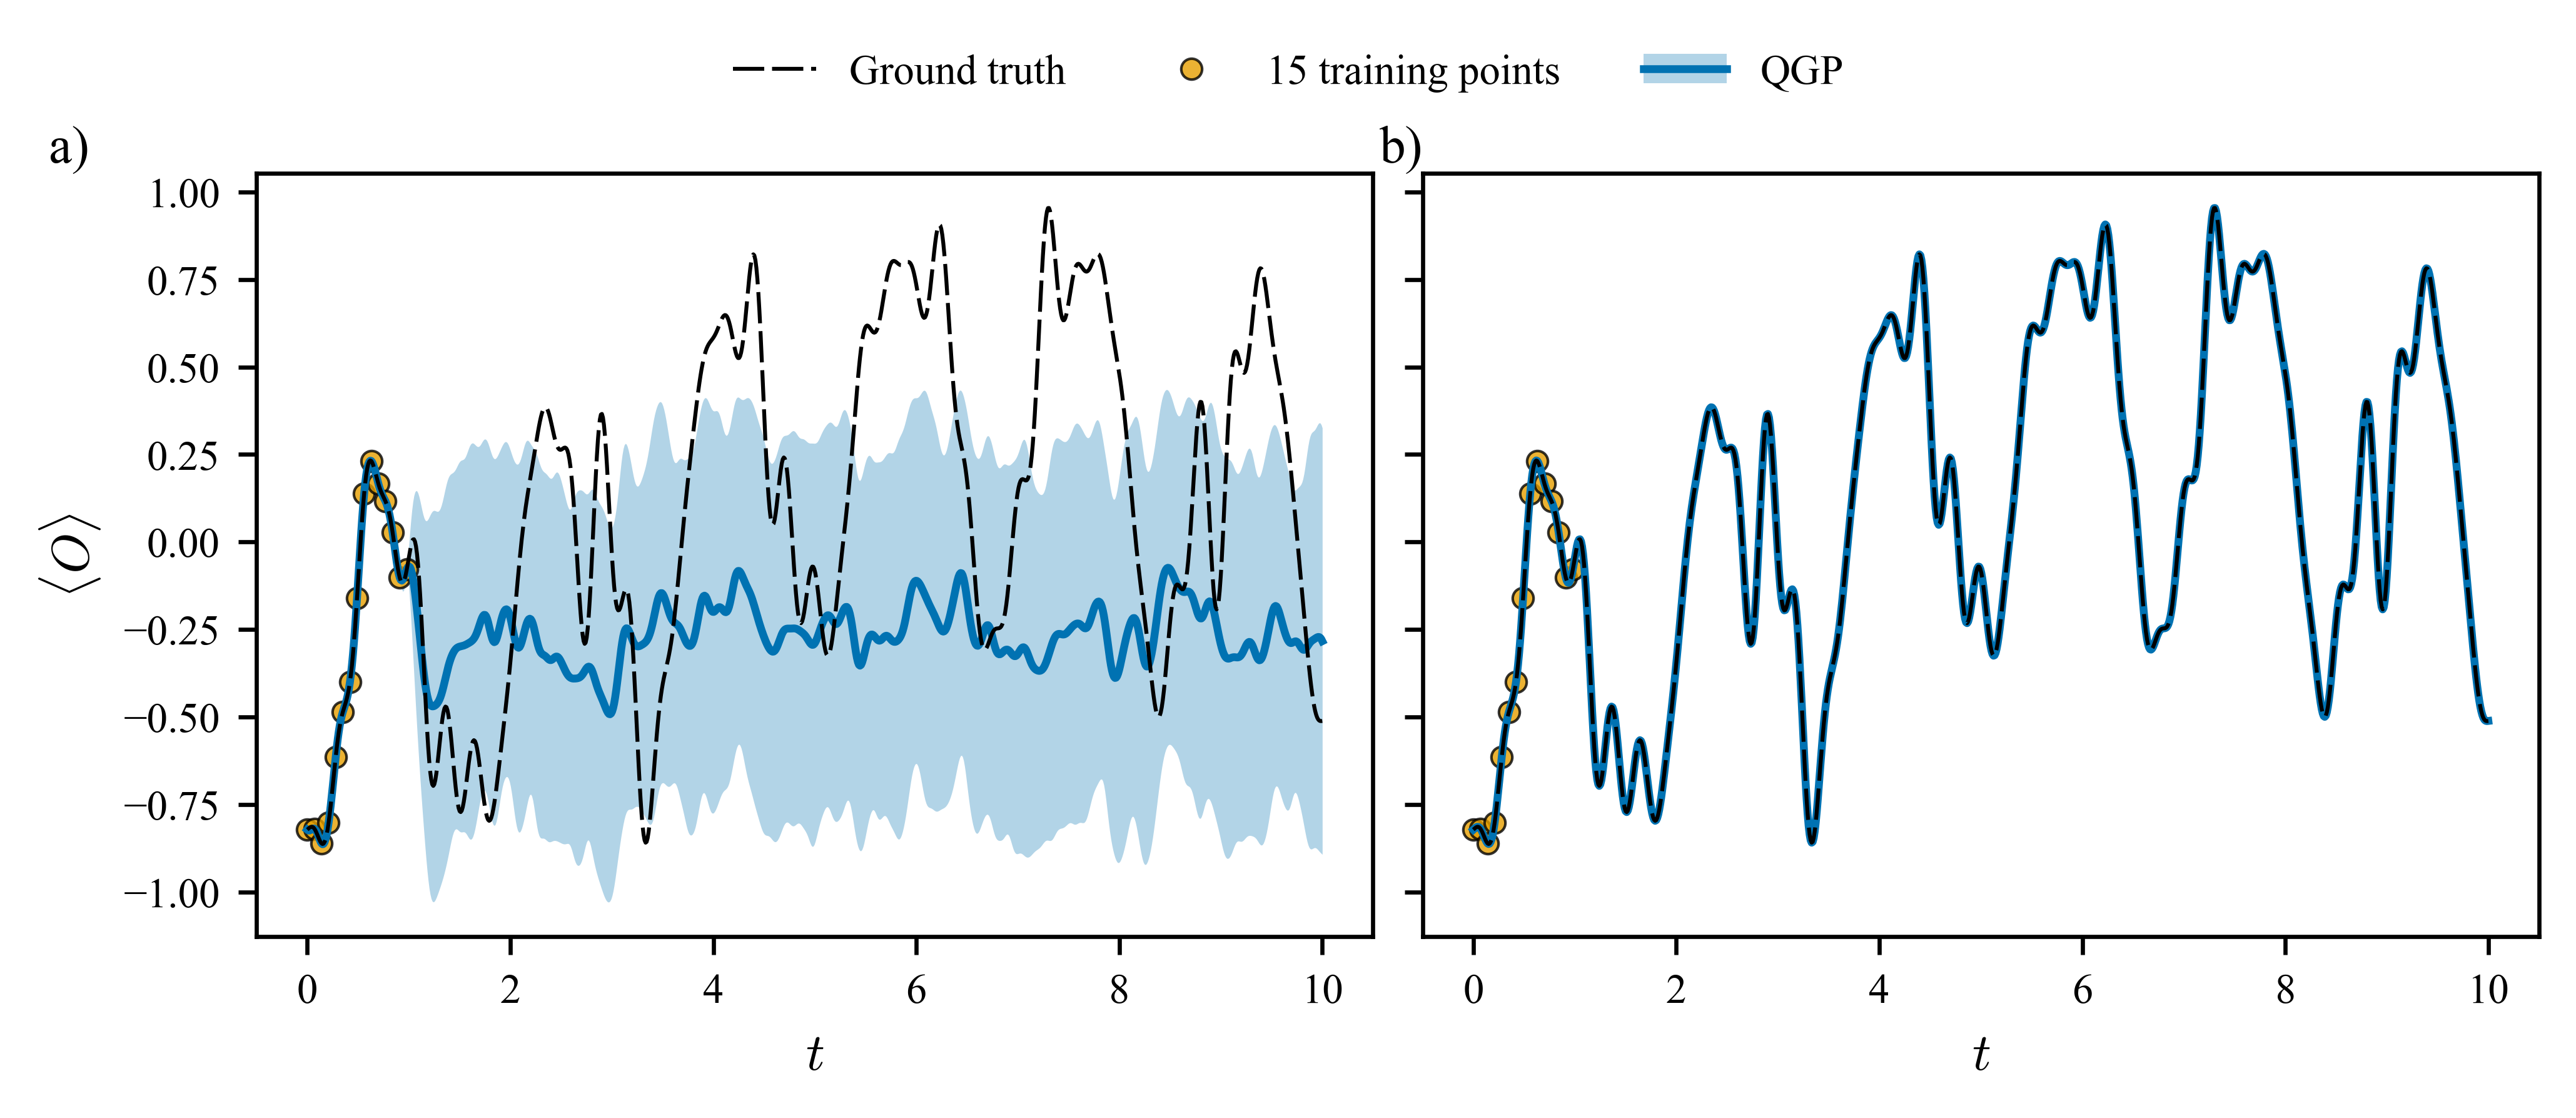

In [21]:
# 1. Create a 1x2 figure
# Multiplying the half-width by 2 to give both subplots proper breathing room
fig, axes = plt.subplots(1, 2, 
                         figsize=(plot_args["fig_width_inches_full"], 2.5), 
                         layout="constrained", sharey=true)

label_font_size = plt.rcParams["axes.labelsize"]

# 2. Left Panel: Initial QGP
ax_left = axes[1]
ax_left, handles, labels = plot_qgp!(ax_left, outputs[train_idxs], train_idxs, 
                                     μ_exact_init, σ_exact_init; 
                                     panel_title="") # Clear the title

                                     label_font_size = plt.rcParams["axes.labelsize"]

# Add text label 'a)' outside top-left, ignored by layout
ax_left.text(-0.15, 1.0, "a)", transform=ax_left.transAxes, 
             verticalalignment="bottom", horizontalalignment="right", fontsize=label_font_size, in_layout=false)

# 3. Right Panel: Optimized QGP
ax_right = axes[2]
# We don't need to save the handles/labels again since they are identical
plot_qgp!(ax_right, outputs[train_idxs], train_idxs, 
          μ_exact_optim, σ_exact_optim; 
          panel_title="") # Clear the title
ax_right.set_ylabel("") # Remove y-label from right panel for cleaner look

# Add text label 'b)' outside top-left, ignored by layout
ax_right.text(-0., 1.0, "b)", transform=ax_right.transAxes, 
              verticalalignment="bottom", horizontalalignment="right", fontsize=label_font_size, in_layout=false)

# 4. Shared Legend at the top
# Anchoring to x=0.5 (center) and y=1.05 (just above the plots)
fig.legend(handles, labels, 
           loc="lower center", 
           bbox_to_anchor=(0.5, 1.03), 
           ncol=3, 
           frameon=false)

# Save and display
isdir("../plots/$(dataset_name)") || mkpath("../plots/$(dataset_name)")
fig.savefig("../plots/$(dataset_name)/qgp_exact_comparison_$(ntp)ntp.pdf", bbox_inches="tight")
display(fig)